# Predictive Maintenance Analysis – AI4I 2020

In [1]:
# Install required packages
%pip install -q ucimlrepo pandas numpy matplotlib seaborn scikit-learn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Environment ready.")

Note: you may need to restart the kernel to use updated packages.
Environment ready.


In [2]:
# Load the AI4I 2020 Predictive Maintenance Dataset from UCI

ai4i_2020_predictive_maintenance_dataset = fetch_ucirepo(id=601)

X = ai4i_2020_predictive_maintenance_dataset.data.features
y = ai4i_2020_predictive_maintenance_dataset.data.targets

df = pd.concat([X, y], axis=1)

print(f"Dataset shape: {df.shape}")

Dataset shape: (10000, 12)


In [3]:
# Initial data inspection

print("First 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

# Descriptive statistics
display(df.describe())

First 5 rows:


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.10,308.60,1551,42.80,0,0,0,0,0,0,0
1,L,298.20,308.70,1408,46.30,3,0,0,0,0,0,0
2,L,298.10,308.50,1498,49.40,5,0,0,0,0,0,0
3,L,298.20,308.60,1433,39.50,7,0,0,0,0,0,0
4,L,298.20,308.70,1408,40.00,9,0,0,0,0,0,0



Data types:


Type                       str
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
TWF                      int64
HDF                      int64
PWF                      int64
OSF                      int64
RNF                      int64
dtype: object

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,300.00,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2.00,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,295.30,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,298.30,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,300.10,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,301.50,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,304.50,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


In [4]:
# 1. How many records contain a machine failure?

total_records = len(df)
failed_records = df["Machine failure"].sum()
non_failed_records = total_records - failed_records

print(f"Total records: {total_records}")
print(f"Records with machine failure: {failed_records}")
print(f"Records without machine failure: {non_failed_records}")

failure_rate = failed_records / total_records * 100
print(f"Overall machine failure rate: {failure_rate:.2f}%")

Total records: 10000
Records with machine failure: 339
Records without machine failure: 9661
Overall machine failure rate: 3.39%


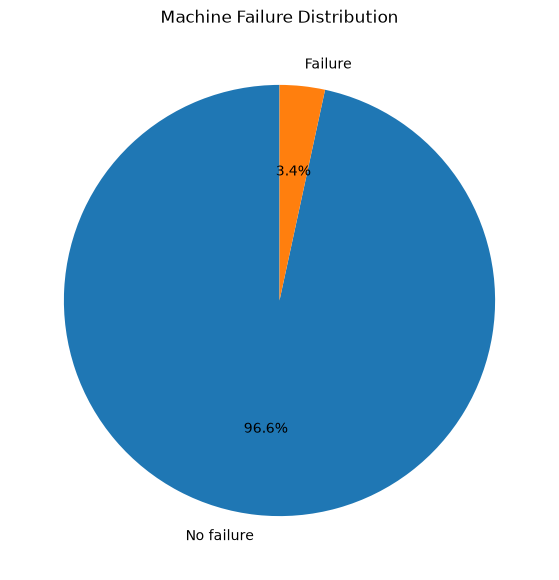

In [5]:
# Machine failure distribution

failure_counts = pd.Series({
    "No failure": non_failed_records,
    "Failure": failed_records
})

plt.figure(figsize=(7, 7))

plt.pie(
    failure_counts.values,
    labels=failure_counts.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Machine Failure Distribution")

plt.show()

In [6]:
# 2. Frequency of each failure mode

failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_mode_counts = df[failure_modes].sum().sort_values(ascending=False)

display(failure_mode_counts)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

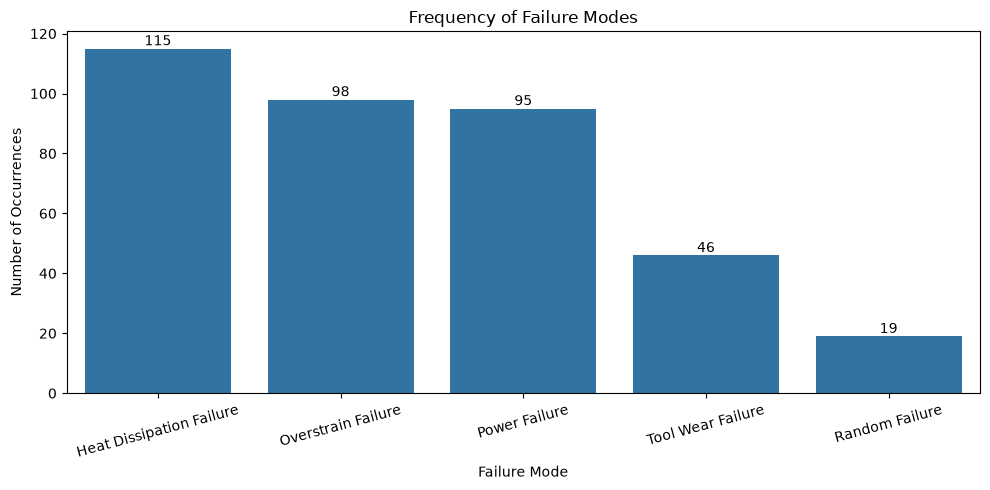

In [7]:
# Visualize failure mode frequencies

failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_mode_counts = (
    df[failure_modes]
    .sum()
    .sort_values(ascending=False)
)

failure_mode_names = {
    "TWF": "Tool Wear Failure",
    "HDF": "Heat Dissipation Failure",
    "PWF": "Power Failure",
    "OSF": "Overstrain Failure",
    "RNF": "Random Failure"
}

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=[failure_mode_names[mode] for mode in failure_mode_counts.index],
    y=failure_mode_counts.values
)

plt.title("Frequency of Failure Modes")
plt.xlabel("Failure Mode")
plt.ylabel("Number of Occurrences")

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [8]:
# 3. How many machine has 2 or more failure modes?

from itertools import combinations

failed_df = df[df["Machine failure"] == 1]

exclusive_combinations = {}

for _, row in failed_df.iterrows():

    active_modes = tuple(
        mode for mode in failure_modes
        if row[mode] == 1
    )

    if len(active_modes) >= 2:
        exclusive_combinations[active_modes] = (
            exclusive_combinations.get(active_modes, 0) + 1
        )

exclusive_combination_summary = pd.DataFrame(
    [
        {
            "Combination": combination,
            "Occurrences": count
        }
        for combination, count in exclusive_combinations.items()
    ]
).sort_values(
    "Occurrences",
    ascending=False
)

display(exclusive_combination_summary)

,Combination,Occurrences
0,"(PWF, OSF)",11
3,"(HDF, OSF)",6
2,"(HDF, PWF)",3
4,"(TWF, OSF)",2
1,"(TWF, RNF)",1
5,"(TWF, PWF, OSF)",1


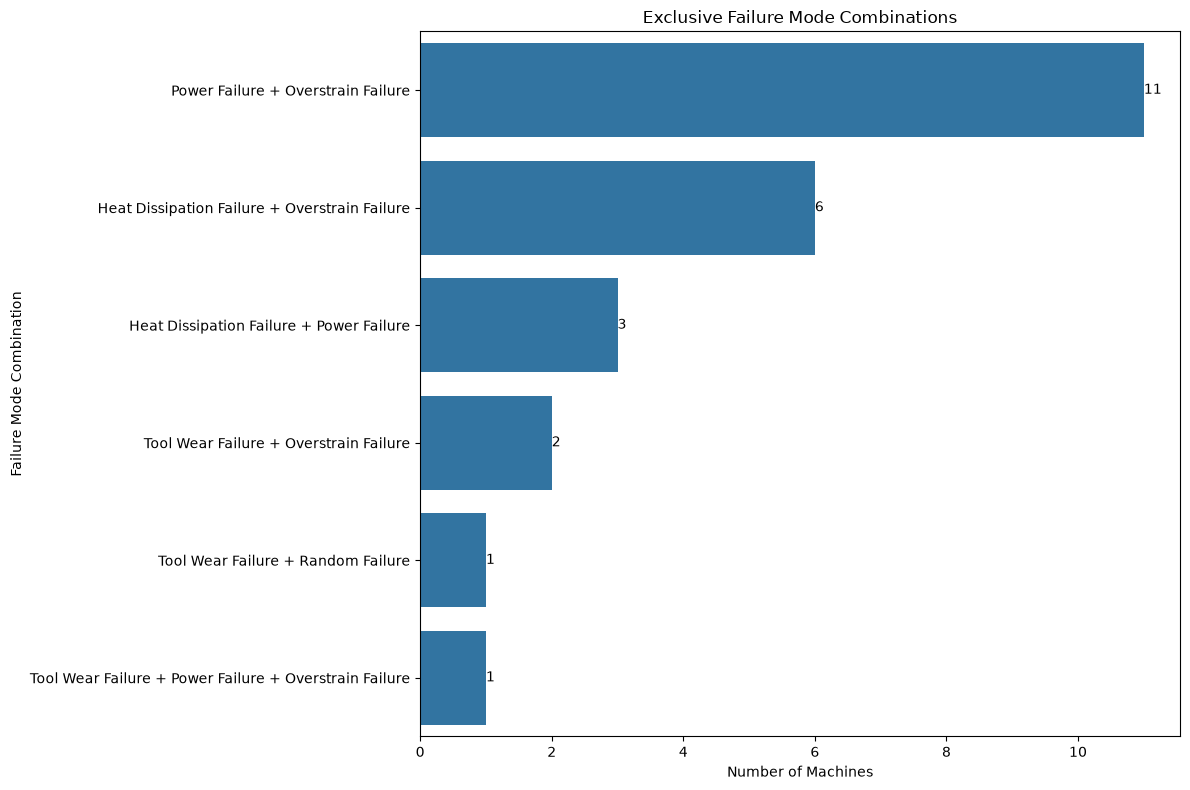

In [9]:
# Visualize exclusive failure mode combinations

exclusive_combination_summary["Failure Combination"] = (
    exclusive_combination_summary["Combination"]
    .apply(
        lambda combination: " + ".join(
            failure_mode_names[mode]
            for mode in combination
        )
    )
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=exclusive_combination_summary,
    x="Occurrences",
    y="Failure Combination"
)

plt.title("Exclusive Failure Mode Combinations")
plt.xlabel("Number of Machines")
plt.ylabel("Failure Mode Combination")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [10]:
# 4. How many machines where machine_failure = 1 has 0 or more failure modes?

failure_count_per_machine = (
    failed_df[failure_modes]
    .sum(axis=1)
    .value_counts()
    .sort_index()
)

display(failure_count_per_machine)

0      9
1    306
2     23
3      1
Name: count, dtype: int64

In [11]:
# Machines where machine_failure = 1 has 0 modes

failed_without_mode = failed_df[
    failed_df[failure_modes].sum(axis=1) == 0
]

display(failed_without_mode)

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
1437,H,298.80,309.90,1439,45.20,40,1,0,0,0,0,0
2749,M,299.70,309.20,1685,28.90,179,1,0,0,0,0,0
4044,M,301.90,310.90,1419,47.70,20,1,0,0,0,0,0
4684,M,303.60,311.80,1421,44.80,101,1,0,0,0,0,0
5536,M,302.30,311.80,1363,54.00,119,1,0,0,0,0,0
5941,L,300.60,310.70,1438,48.50,78,1,0,0,0,0,0
6478,L,300.50,309.80,1663,29.10,145,1,0,0,0,0,0
8506,L,298.40,309.60,1710,27.30,163,1,0,0,0,0,0
9015,L,297.20,308.10,1431,49.70,210,1,0,0,0,0,0


In [12]:
# 5. Failed records by product type

failed_by_type = (
    failed_df["Type"]
    .value_counts()
    .sort_index()
)

display(failed_by_type)

Type
H     21
L    235
M     83
Name: count, dtype: int64

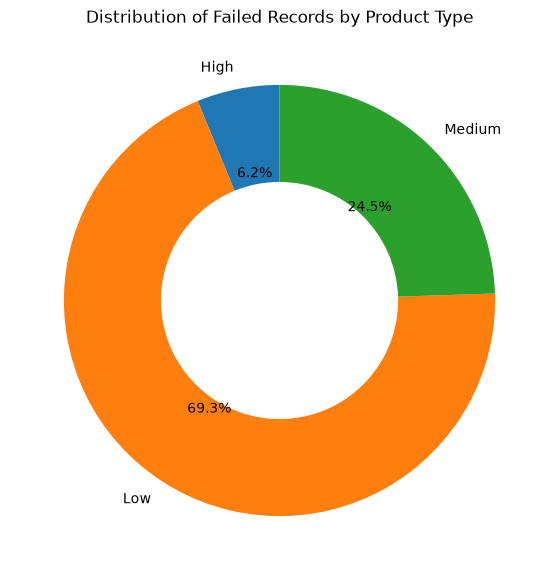

In [13]:
# Visualize the distribution of failed records by product type

type_names = {
    "L": "Low",
    "M": "Medium",
    "H": "High"
}

labels = [
    type_names[type_code]
    for type_code in failed_by_type.index
]

plt.figure(figsize=(7, 7))

plt.pie(
    failed_by_type.values,
    labels=labels,
    autopct="%.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Distribution of Failed Records by Product Type")

plt.show()

In [14]:
# 6. Failure mode frequencies by product type

failure_by_type = (
    failed_df
    .groupby("Type")[failure_modes]
    .sum()
)

failure_by_type.index = failure_by_type.index.map(type_names)

failure_by_type = failure_by_type.reindex(
    ["Low", "Medium", "High"]
)

display(failure_by_type)

,TWF,HDF,PWF,OSF,RNF
Type,,,,,
Low,25,76,59,87,1
Medium,14,31,31,9,0
High,7,8,5,2,0


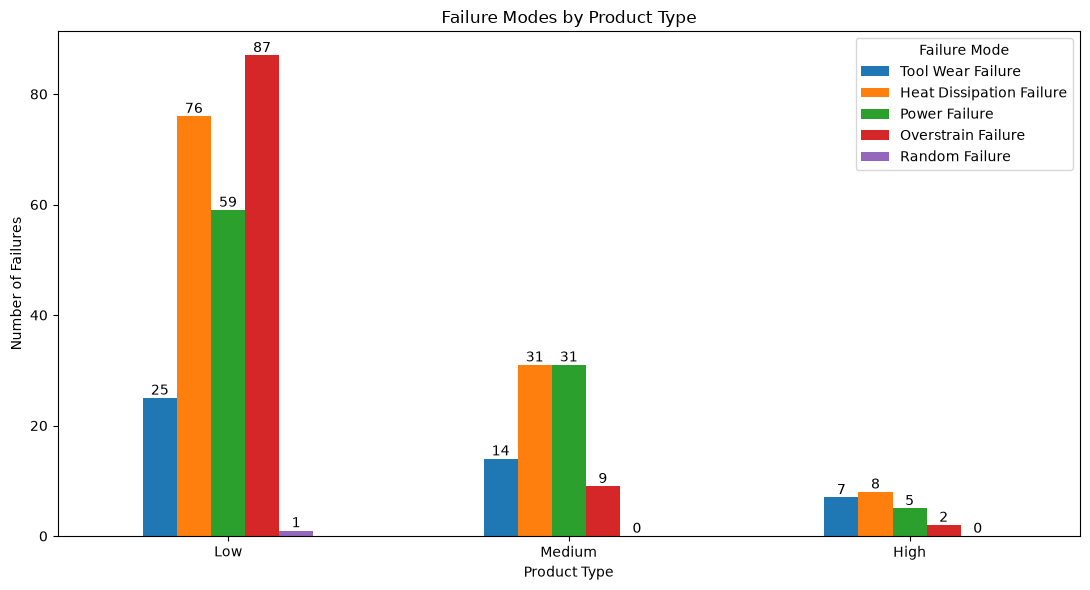

In [15]:
# Visualize failure modes by product type

failure_mode_names = {
    "TWF": "Tool Wear Failure",
    "HDF": "Heat Dissipation Failure",
    "PWF": "Power Failure",
    "OSF": "Overstrain Failure",
    "RNF": "Random Failure"
}

failure_by_type_plot = failure_by_type.rename(
    columns=failure_mode_names
)

ax = failure_by_type_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Failure Modes by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Number of Failures")

plt.xticks(rotation=0)
plt.legend(title="Failure Mode")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [16]:
# 7. Most common tool wear [in minutes] values among failed machines

failed_tool_wear = (
    failed_df["Tool wear"]
    .value_counts()
    .head(3)
    .sort_values(ascending=False)
)

display(failed_tool_wear)

Tool wear
207    9
208    8
203    7
Name: count, dtype: int64

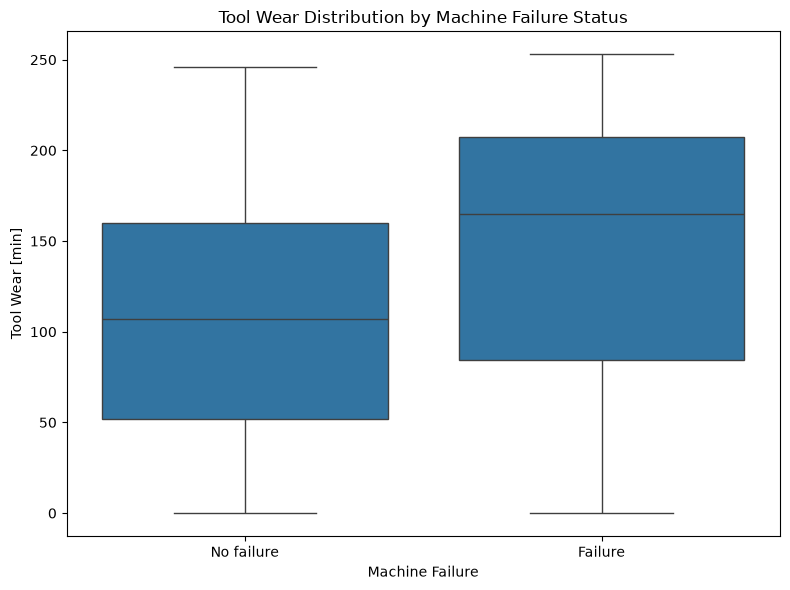

In [17]:
# 8. Tool wear distribution: failed vs. non-failed machines

tool_wear_by_failure = df.copy()

tool_wear_by_failure["Failure Status"] = (
    tool_wear_by_failure["Machine failure"]
    .map({
        0: "No failure",
        1: "Failure"
    })
)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=tool_wear_by_failure,
    x="Failure Status",
    y="Tool wear"
)

plt.title("Tool Wear Distribution by Machine Failure Status")
plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear [min]")

plt.tight_layout()
plt.show()

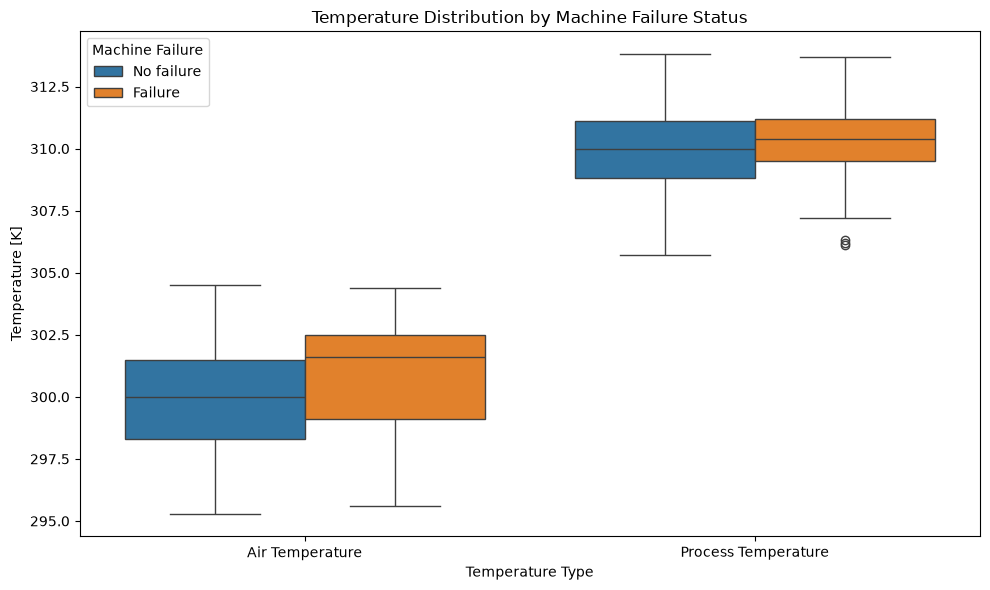

In [18]:
# 9. Air and process temperature distribution by machine failure status

temperature_by_failure = df.copy()

temperature_by_failure["Failure Status"] = (
    temperature_by_failure["Machine failure"]
    .map({
        0: "No failure",
        1: "Failure"
    })
)

temperature_long = temperature_by_failure.melt(
    id_vars="Failure Status",
    value_vars=["Air temperature", "Process temperature"],
    var_name="Temperature Type",
    value_name="Temperature"
)

temperature_long["Temperature Type"] = (
    temperature_long["Temperature Type"]
    .map({
        "Air temperature": "Air Temperature",
        "Process temperature": "Process Temperature"
    })
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=temperature_long,
    x="Temperature Type",
    y="Temperature",
    hue="Failure Status"
)

plt.title("Temperature Distribution by Machine Failure Status")
plt.xlabel("Temperature Type")
plt.ylabel("Temperature [K]")

plt.legend(title="Machine Failure")

plt.tight_layout()
plt.show()

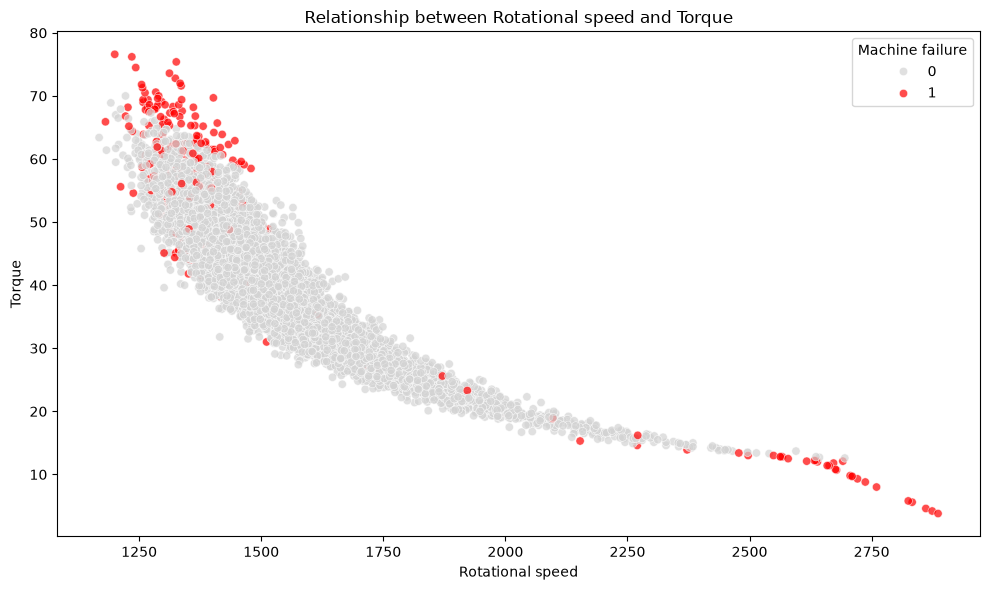

In [19]:
# 10. Create a scatterplot to show the relationship between Rotational speed and Torque

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Rotational speed', 
    y='Torque', 
    hue='Machine failure',
    palette={0: 'lightgray', 1: 'red'}, 
    alpha=0.7
)

plt.title('Relationship between Rotational speed and Torque')
plt.tight_layout()
plt.show()

In [20]:
# logistic regression to predict whether a machine will fail based on its physical sensor data.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df[['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']]
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy score: 0.821

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [ ]:
# Columns: ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
test_cases = pd.DataFrame([
    [298.0, 308.5, 1500, 35.0, 10],   # 1. Definitely won't fail (normal, low wear, optimal values)
    [303.0, 312.0, 1300, 60.0, 215],  # 2. Definitely fails (high tool wear and high torque / overload)
    [301.0, 310.0, 1400, 48.0, 185]   # 3. Edge case (increasing wear and moderately high load)
], columns=['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear'])

predictions = model.predict(test_cases)
probabilities = model.predict_proba(test_cases)

for i, pred in enumerate(predictions):
    fail_prob = probabilities[i][1] * 100
    print(f"Test case {i+1} -> Prediction: {pred} (Failure probability: {fail_prob:.1f}%)")

Test case 1 -> Prediction: 0 (Failure probability: 0.8%)
Test case 2 -> Prediction: 1 (Failure probability: 96.7%)
Test case 3 -> Prediction: 1 (Failure probability: 75.9%)
